In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("clean_vgsales.csv")
df.head()

,Unnamed: 0,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.83
3,3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.38


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 16291 entries, 0 to 16290
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    16291 non-null  int64  
 1   Rank          16291 non-null  int64  
 2   Name          16291 non-null  str    
 3   Platform      16291 non-null  str    
 4   Year          16291 non-null  float64
 5   Genre         16291 non-null  str    
 6   Publisher     16291 non-null  str    
 7   NA_Sales      16291 non-null  float64
 8   EU_Sales      16291 non-null  float64
 9   JP_Sales      16291 non-null  float64
 10  Other_Sales   16291 non-null  float64
 11  Global_Sales  16291 non-null  float64
dtypes: float64(6), int64(2), str(4)
memory usage: 2.2 MB


,Unnamed: 0,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000
mean,8288.086060,8290.190228,2006.405561,0.265647,0.147731,0.078833,0.048426,0.540637
std,4792.375439,4792.654450,5.832412,0.822432,0.509303,0.311879,0.190083,1.567460
min,0.000000,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4130.500000,4132.500000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8290.000000,8292.000000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12437.500000,12439.500000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.480000
max,16597.000000,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [4]:
# Drop non-useful columns
df = df.drop(columns=["Name"], errors='ignore')

# One-hot encode categorical features
df = pd.get_dummies(df, columns=["Platform", "Genre", "Publisher"], drop_first=True)

In [5]:
X = df.drop("Global_Sales", axis=1)
y = df["Global_Sales"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

In [8]:
et_model = ExtraTreesRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

et_model.fit(X_train, y_train)

et_preds = et_model.predict(X_test)

In [11]:
from sklearn.metrics import mean_squared_error, r2_score

# Predictions
rf_preds = rf_model.predict(X_test)
et_preds = et_model.predict(X_test)

# Metrics
rf_mse = mean_squared_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

et_mse = mean_squared_error(y_test, et_preds)
et_r2 = r2_score(y_test, et_preds)

# Now this will work
results = pd.DataFrame({
    "Model": ["Random Forest", "Extra Trees"],
    "MSE": [rf_mse, et_mse],
    "R2 Score": [rf_r2, et_r2]
})

print(results)

           Model       MSE  R2 Score
0  Random Forest  0.691837  0.838284
1    Extra Trees  0.669785  0.843438


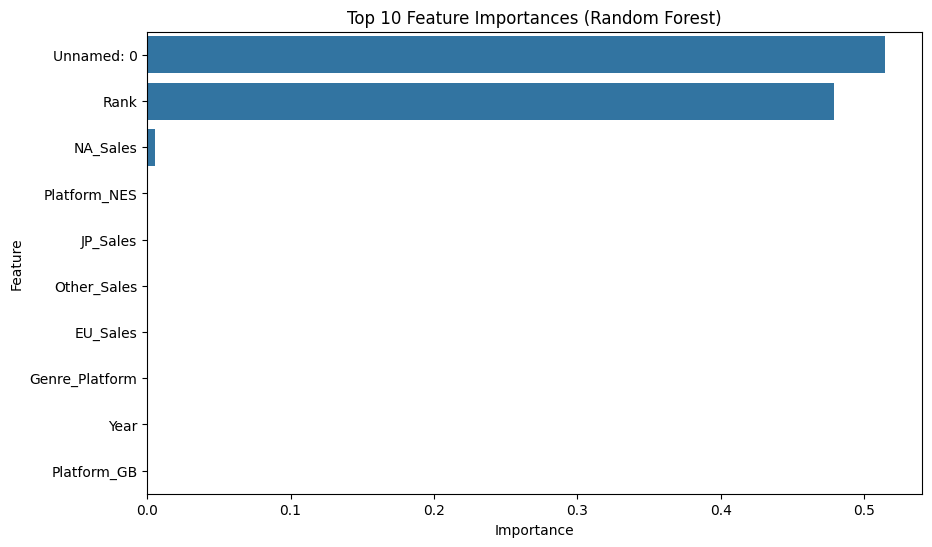

In [12]:
importances = rf_model.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot top 10
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp.head(10))
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()